# First Dragon, First Win? 🐉
### A Data Science Lifecycle Investigation of Professional League of Legends
**DSC 80 @ UCSD — Final Project**
**Author:** Chu Pei

This notebook investigates 2022 professional *League of Legends* esports matches
(data from [Oracle's Elixir](https://oracleselixir.com/tools/downloads)) to understand
how securing the **first dragon** of the game relates to a team's chance of winning,
and to build a model that predicts game outcomes from early-game state.

🔗 **Project website:** https://chewythechoochoo.github.io/dsc80Proj/

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from pathlib import Path

# Render figures as static images inline so they appear in the exported PDF/HTML.
# (The website embeds the interactive versions saved to assets/ via save_fig.)
pio.renderers.default = "png"

pd.set_option("display.max_columns", None)
ASSETS = Path("assets")
ASSETS.mkdir(exist_ok=True)

# Helper: save a plotly figure as a lightweight, CDN-linked HTML file for the website.
def save_fig(fig, name):
    fig.write_html(ASSETS / f"{name}.html", include_plotlyjs="cdn")
    return fig

## Introduction

*League of Legends* is the most-watched esport in the world, and a huge amount of
strategic discussion centers on **early-game objectives**. One of the earliest neutral
objectives is the **dragon**, which grants the team that slays it a permanent,
stacking buff. A natural question for players, coaches, and analysts is:

> **Does securing the first dragon of the game give a team a higher chance of winning?**

We use Oracle's Elixir's 2022 match dataset, which contains one row per player and per
team for every professional game tracked that year. We focus on the **team-level rows**
(`position == "team"`). The columns most relevant to our question are:

| Column | Description |
| --- | --- |
| `result` | 1 if the team won the game, 0 if it lost. |
| `firstdragon` | 1 if the team secured the first dragon of the game. |
| `firstblood` | 1 if the team got the first kill of the game. |
| `firsttower` | 1 if the team destroyed the first tower. |
| `golddiffat15` | The team's gold lead/deficit at 15 minutes. |
| `xpdiffat15` | The team's experience lead/deficit at 15 minutes. |
| `csdiffat15` | The team's creep-score (farm) lead/deficit at 15 minutes. |
| `league` | The professional league/competition the game belongs to. |
| `gamelength` | Length of the game in seconds. |

In [2]:
# Load the full dataset (one row per player and per team).
lol = pd.read_csv("2022_LoL_esports_match_data_from_OraclesElixir.csv", low_memory=False)
print("Full dataset shape:", lol.shape)
lol[["gameid", "league", "position", "teamname", "result", "firstdragon"]].head()

Full dataset shape: (150348, 165)


,gameid,league,position,teamname,result,firstdragon
0,ESPORTSTMNT01_2690210,LCKC,top,HANJIN BRION Challengers,0,NaN
1,ESPORTSTMNT01_2690210,LCKC,jng,HANJIN BRION Challengers,0,NaN
2,ESPORTSTMNT01_2690210,LCKC,mid,HANJIN BRION Challengers,0,NaN
3,ESPORTSTMNT01_2690210,LCKC,bot,HANJIN BRION Challengers,0,NaN
4,ESPORTSTMNT01_2690210,LCKC,sup,HANJIN BRION Challengers,0,NaN


## Data Cleaning and Exploratory Data Analysis

### Data Cleaning

Our cleaning steps follow directly from the data generating process:

1. **Keep only team rows.** Each game produces 10 player rows and 2 team rows. Because
   our question is about *teams* winning, we keep only rows where `position == "team"`.
2. **Drop rows missing the core outcome/treatment.** A handful of rows lack `result`
   or `firstdragon`; these games cannot inform our question, so we drop them.
3. **Cast booleans to integers.** `result`, `firstdragon`, `firstblood`, and
   `firsttower` are stored as 0/1 flags; we cast them to `int` so they can be averaged
   (a mean of a 0/1 column is a win rate / proportion) and fed to models.
4. **Keep the at-15-minutes differentials as-is.** `golddiffat15`, `xpdiffat15`, and
   `csdiffat15` are already signed numeric leads; we leave them numeric. (Their
   missingness is analyzed in detail in the next section.)

In [3]:
# 1. Keep only the team-level rows.
teams = lol[lol["position"] == "team"].copy()

# 2. Drop rows missing the core outcome / treatment.
teams = teams.dropna(subset=["result", "firstdragon"])

# 3. Cast 0/1 flag columns to integers.
for col in ["result", "firstdragon", "firstblood", "firsttower"]:
    teams[col] = teams[col].astype(int)

print("Cleaned team-level shape:", teams.shape)
teams[["league", "teamname", "result", "firstblood", "firstdragon",
       "firsttower", "golddiffat15", "xpdiffat15"]].head()

Cleaned team-level shape: (22872, 165)


,league,teamname,result,firstblood,firstdragon,firsttower,golddiffat15,xpdiffat15
10,LCKC,HANJIN BRION Challengers,0,1,0,1,107.0,-1617.0
11,LCKC,Nongshim Esports Academy,1,0,1,0,-107.0,1617.0
22,LCKC,T1 Esports Academy,0,0,0,0,-1763.0,-906.0
23,LCKC,Liiv SANDBOX Youth,1,1,1,1,1763.0,906.0
34,LPL,Oh My God,1,0,0,1,NaN,NaN


### Univariate Analysis

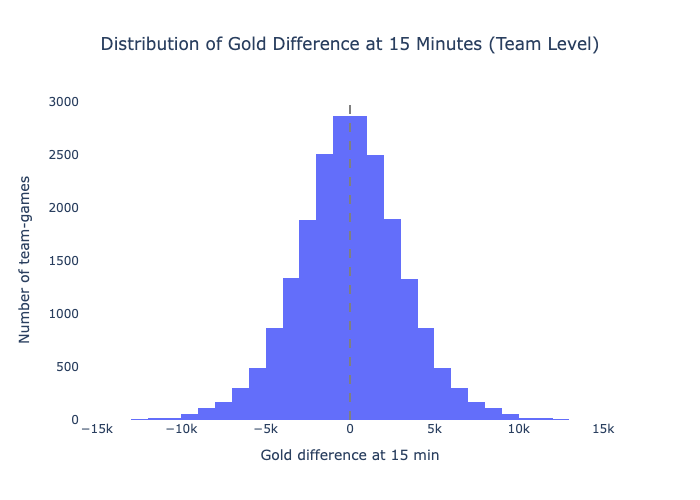

In [4]:
# Distribution of the gold difference at 15 minutes (a key early-game state variable).
fig = px.histogram(
    teams.dropna(subset=["golddiffat15"]),
    x="golddiffat15",
    nbins=60,
    title="Distribution of Gold Difference at 15 Minutes (Team Level)",
    labels={"golddiffat15": "Gold difference at 15 min"},
)
fig.update_layout(yaxis_title="Number of team-games", plot_bgcolor="white", title_x=0.5)
fig.add_vline(x=0, line_dash="dash", line_color="gray")
save_fig(fig, "univariate_golddiff")
fig.show()

The gold difference at 15 minutes is roughly symmetric and centered near zero, which
makes sense: in any game one team's lead is the other team's deficit, so the
team-level distribution is nearly mirror-symmetric about 0. The spread (many games
with leads of several thousand gold) shows that meaningful early advantages are common.

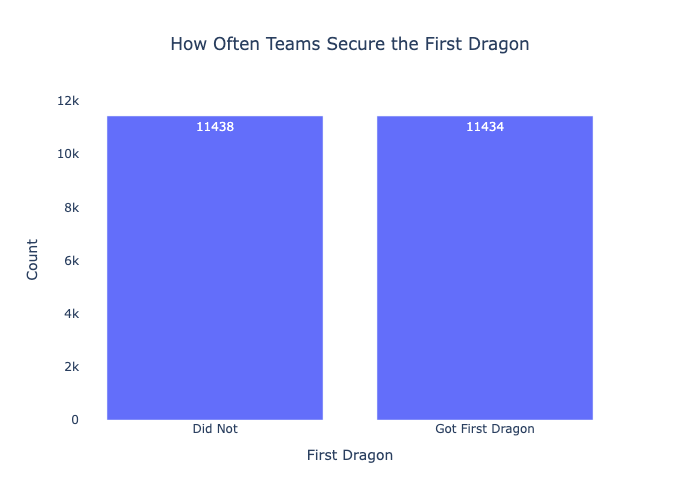

In [5]:
# Distribution of a single categorical column: how often teams secure the first dragon.
fd_counts = (
    teams["firstdragon"].map({1: "Got First Dragon", 0: "Did Not"})
    .value_counts()
    .rename_axis("First Dragon")
    .reset_index(name="Count")
)
fig = px.bar(
    fd_counts, x="First Dragon", y="Count", text="Count",
    title="How Often Teams Secure the First Dragon",
)
fig.update_layout(plot_bgcolor="white", title_x=0.5)
save_fig(fig, "univariate_firstdragon")
fig.show()

As expected, the first dragon is split almost exactly 50/50 across team-games (every game has exactly one team that gets it and one that does not).

### Bivariate Analysis

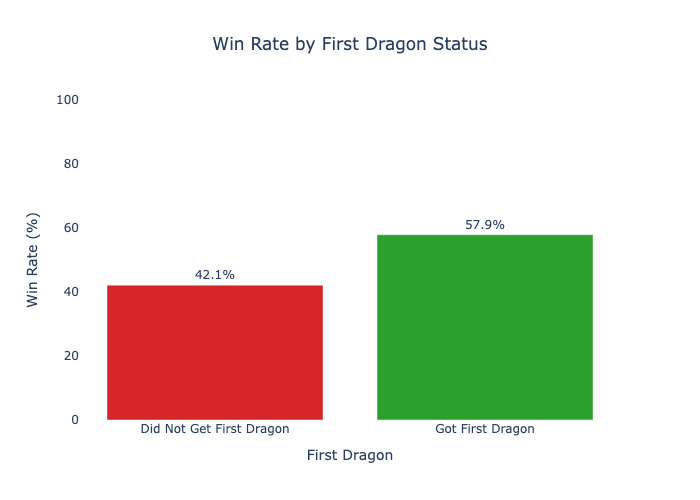

In [6]:
# Relationship between securing the first dragon and the win rate.
dragon_wr = (
    teams.groupby("firstdragon")["result"].mean().reset_index()
)
dragon_wr["First Dragon"] = dragon_wr["firstdragon"].map(
    {1: "Got First Dragon", 0: "Did Not Get First Dragon"})
dragon_wr["Win Rate (%)"] = dragon_wr["result"] * 100

fig = px.bar(
    dragon_wr, x="First Dragon", y="Win Rate (%)", text="Win Rate (%)",
    title="Win Rate by First Dragon Status",
    color="First Dragon",
    color_discrete_sequence=["#d62728", "#2ca02c"],
)
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
fig.update_layout(yaxis_range=[0, 100], plot_bgcolor="white", title_x=0.5,
                  showlegend=False)
save_fig(fig, "bivariate_dragon_winrate")
fig.show()

Teams that secure the first dragon win clearly more often than teams that do not.
This visible gap is exactly the association we formally test in the Hypothesis Testing
section.

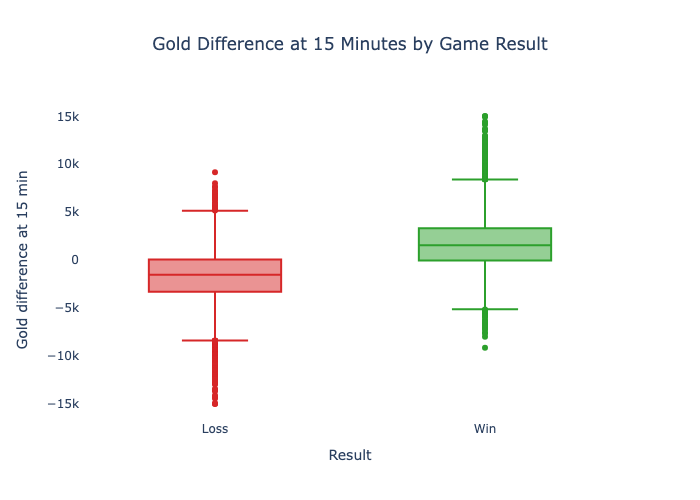

In [7]:
# Second bivariate plot: gold difference at 15 split by eventual result.
fig = px.box(
    teams.dropna(subset=["golddiffat15"]).assign(
        Result=lambda d: d["result"].map({1: "Win", 0: "Loss"})),
    x="Result", y="golddiffat15", color="Result",
    title="Gold Difference at 15 Minutes by Game Result",
    labels={"golddiffat15": "Gold difference at 15 min"},
    color_discrete_sequence=["#d62728", "#2ca02c"],
)
fig.update_layout(plot_bgcolor="white", title_x=0.5, showlegend=False)
save_fig(fig, "bivariate_gold_result")
fig.show()

Teams that eventually win tend to already hold a gold lead at 15 minutes, suggesting early-game state is predictive of the final result — motivating our prediction problem later.

### Interesting Aggregates

In [8]:
# Pivot: win rate by combinations of early objectives (first dragon x first blood).
pivot = (
    teams.pivot_table(index="firstdragon", columns="firstblood",
                      values="result", aggfunc="mean")
    .round(3)
)
pivot.index = pivot.index.map({0: "No First Dragon", 1: "First Dragon"})
pivot.columns = pivot.columns.map({0: "No First Blood", 1: "First Blood"})
print(pivot.to_markdown())
pivot

| firstdragon     |   No First Blood |   First Blood |
|:----------------|-----------------:|--------------:|
| No First Dragon |            0.324 |         0.533 |
| First Dragon    |            0.468 |         0.675 |


firstblood,No First Blood,First Blood
firstdragon,,
No First Dragon,0.324,0.533
First Dragon,0.468,0.675


This pivot table shows win rate broken down by whether a team got the first dragon
(rows) and the first blood (columns). Win rate increases as a team secures *more* early
objectives: teams with neither advantage win least often, teams with both win most
often, and the two objectives appear to contribute roughly additively.

## Assessment of Missingness

### NMAR Analysis

We believe the `golddiffat15` column (along with `xpdiffat15` and `csdiffat15`) is
**not** NMAR. Its missingness is **not** explained by the gold value itself; rather,
some leagues and tournaments simply did not have the detailed timeline tracking that
produces 15-minute snapshots. In other words, whether `golddiffat15` is recorded
depends on an *observed* column (`league`), which makes it **MAR**, not NMAR.

A column that is a more plausible **NMAR** candidate would be something like a
voluntary post-game player rating or survey response (not present here): players who
performed poorly might be systematically less likely to report, so the missingness
would depend on the unobserved value itself. To turn such a hypothetical column from
NMAR into MAR, we would want to obtain additional data — e.g., the player's measured
in-game performance — that explains the propensity to respond.

### Missingness Dependency

We test whether the missingness of `golddiffat15` depends on other columns using
permutation tests. We expect its missingness to **depend on `league`** (some leagues
never recorded timeline data) but to be **independent of `result`** (whether a team
won has nothing to do with whether the broadcast tracked 15-minute gold).

In [9]:
# Create the missingness indicator for golddiffat15.
miss = teams.copy()
miss["g15_missing"] = miss["golddiffat15"].isna()
print("Overall missingness rate of golddiffat15:", round(miss['g15_missing'].mean(), 3))

# ---- Dependency on LEAGUE (categorical): use Total Variation Distance (TVD) ----
def tvd(dist_a, dist_b):
    cats = dist_a.index.union(dist_b.index)
    a = dist_a.reindex(cats, fill_value=0)
    b = dist_b.reindex(cats, fill_value=0)
    return np.abs(a - b).sum() / 2

obs_league = tvd(
    miss[miss["g15_missing"]]["league"].value_counts(normalize=True),
    miss[~miss["g15_missing"]]["league"].value_counts(normalize=True),
)

rng = np.random.default_rng(0)
n_reps = 1000
league_vals = miss["league"].values
mask = miss["g15_missing"].values
tvds = np.empty(n_reps)
for i in range(n_reps):
    shuffled = rng.permutation(mask)
    a = pd.Series(league_vals[shuffled]).value_counts(normalize=True)
    b = pd.Series(league_vals[~shuffled]).value_counts(normalize=True)
    tvds[i] = tvd(a, b)
p_league = float(np.mean(tvds >= obs_league))
print(f"League:  observed TVD = {obs_league:.3f}, permutation p-value = {p_league:.3f}")

Overall missingness rate of golddiffat15: 0.07
League:  observed TVD = 0.987, permutation p-value = 0.000


Result:  observed diff in mean = 0.0000, permutation p-value = 1.000


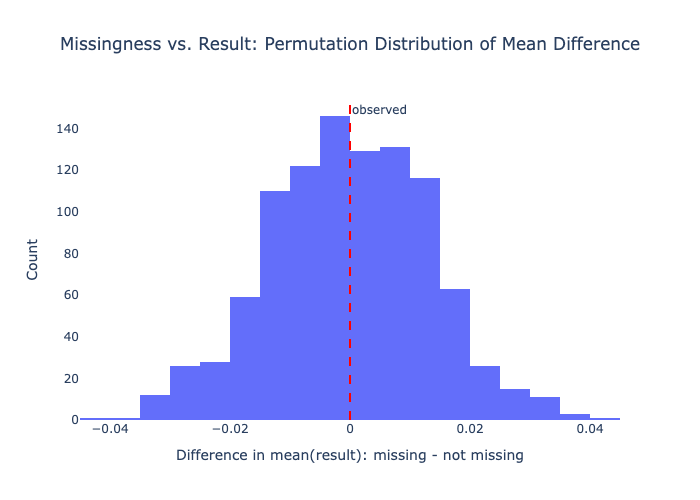

In [10]:
# ---- Dependency on RESULT (numeric 0/1): difference in mean result ----
obs_result = (
    miss[miss["g15_missing"]]["result"].mean()
    - miss[~miss["g15_missing"]]["result"].mean()
)
result_vals = miss["result"].values
diffs = np.empty(n_reps)
for i in range(n_reps):
    shuffled = rng.permutation(mask)
    diffs[i] = result_vals[shuffled].mean() - result_vals[~shuffled].mean()
p_result = float(np.mean(np.abs(diffs) >= np.abs(obs_result)))
print(f"Result:  observed diff in mean = {obs_result:.4f}, permutation p-value = {p_result:.3f}")

# Visualize the result-dependency permutation distribution.
fig = px.histogram(
    pd.DataFrame({"diff": diffs}), x="diff", nbins=40,
    title="Missingness vs. Result: Permutation Distribution of Mean Difference",
    labels={"diff": "Difference in mean(result): missing - not missing"},
)
fig.add_vline(x=obs_result, line_dash="dash", line_color="red",
              annotation_text="observed")
fig.update_layout(plot_bgcolor="white", title_x=0.5, yaxis_title="Count")
save_fig(fig, "missingness_result")
fig.show()

**Interpretation.** The missingness of `golddiffat15` **does depend on `league`**
(observed TVD is far larger than anything seen under the null, p-value ≈ 0): entire
leagues such as LPL and LDL never recorded 15-minute timeline data. In contrast, the
missingness **does not depend on `result`** (the observed difference is tiny and the
permutation p-value is large), which matches our intuition that data-tracking decisions
are unrelated to who won. Because the missingness is explained by an observed column
(`league`), `golddiffat15` is **MAR**, not NMAR.

## Hypothesis Testing

We now formally test the association we saw in the EDA.

- **Null hypothesis ($H_0$):** Teams that secure the first dragon have the **same** win
  rate as teams that do not; any observed difference is due to random chance.
- **Alternative hypothesis ($H_1$):** Teams that secure the first dragon have a
  **higher** win rate than teams that do not.
- **Test statistic:** Difference in win rates
  (win rate *with* first dragon − win rate *without* first dragon). We use this directed
  statistic because the alternative is one-sided.
- **Significance level:** $\alpha = 0.05$.

We use a **permutation test**: under $H_0$, the `firstdragon` label is exchangeable, so
we repeatedly shuffle it and recompute the difference in win rates to build the null
distribution.

In [11]:
got = teams[teams["firstdragon"] == 1]["result"]
no = teams[teams["firstdragon"] == 0]["result"]
obs_diff = got.mean() - no.mean()
print(f"Win rate WITH first dragon:    {got.mean():.4f}")
print(f"Win rate WITHOUT first dragon: {no.mean():.4f}")
print(f"Observed difference:           {obs_diff:.4f}")

rng = np.random.default_rng(42)
labels = teams["firstdragon"].values
res = teams["result"].values
n_reps = 10000
perm_diffs = np.empty(n_reps)
for i in range(n_reps):
    s = rng.permutation(labels)
    perm_diffs[i] = res[s == 1].mean() - res[s == 0].mean()
p_value = float(np.mean(perm_diffs >= obs_diff))
print(f"Permutation p-value (one-sided): {p_value:.5f}")
print(f"Largest difference under the null: {perm_diffs.max():.4f}")

Win rate WITH first dragon:    0.5786
Win rate WITHOUT first dragon: 0.4214
Observed difference:           0.1572
Permutation p-value (one-sided): 0.00000
Largest difference under the null: 0.0233


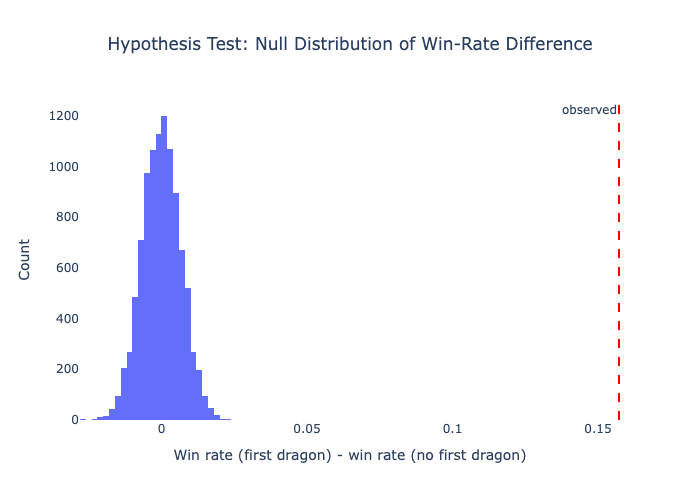

In [12]:
fig = px.histogram(
    pd.DataFrame({"diff": perm_diffs}), x="diff", nbins=50,
    title="Hypothesis Test: Null Distribution of Win-Rate Difference",
    labels={"diff": "Win rate (first dragon) - win rate (no first dragon)"},
)
fig.add_vline(x=obs_diff, line_dash="dash", line_color="red",
              annotation_text="observed", annotation_position="top left")
fig.update_layout(plot_bgcolor="white", title_x=0.5, yaxis_title="Count")
save_fig(fig, "hypothesis_perm")
fig.show()

**Conclusion.** The observed difference in win rates (~15.7 percentage points) is far
outside the entire null distribution (whose largest value is only ~2.3 percentage
points), giving a p-value of essentially 0, well below $\alpha = 0.05$. We **reject the
null hypothesis**. The data provide strong evidence that securing the first dragon is
associated with a higher win rate. Because this is a statistical test on observational
data rather than a randomized controlled experiment, we cannot claim that the first
dragon *causes* wins, nor prove the result with certainty.

## Framing a Prediction Problem

**Prediction problem:** Predict whether a team **wins** a game (`result`) from its
**early-game state**. This is a **binary classification** problem (win = 1, loss = 0).

**Response variable.** We predict `result` because it is the outcome of central interest
and directly extends the question we investigated above.

**Features and "time of prediction."** To respect the time of prediction, we only use
information available **by the 15-minute mark** of the game: the early-objective flags
`firstblood`, `firstdragon`, `firsttower`, and the 15-minute differentials
`golddiffat15`, `xpdiffat15`, `csdiffat15`. We deliberately exclude end-of-game
information (e.g., total towers/barons, game length) that would not be known mid-game.

**Evaluation metric.** We use **accuracy**. The classes are essentially balanced (every
game has exactly one winner and one loser, so ~50% of team-rows are wins), which makes
accuracy easy to interpret and not misleading the way it can be on imbalanced data. We
prefer it over F1 here precisely because there is no rare positive class to protect.

In [13]:
from sklearn.model_selection import train_test_split

FEATURES = ["firstblood", "firstdragon", "firsttower",
            "golddiffat15", "xpdiffat15", "csdiffat15"]

# Restrict to rows where the early-game features are present (drops leagues that never
# tracked 15-minute timeline data, e.g. LPL/LDL, as discussed in the Missingness section).
model_df = teams.dropna(subset=FEATURES).copy()
for c in ["firstblood", "firstdragon", "firsttower"]:
    model_df[c] = model_df[c].astype(int)

X = model_df[FEATURES + ["league"]]   # carry league for the later fairness analysis
y = model_df["result"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)
print("Modeling rows:", model_df.shape[0])
print("Train / test sizes:", X_train.shape[0], "/", X_test.shape[0])
print("Win rate in data (class balance):", round(y.mean(), 3))

Modeling rows: 21282
Train / test sizes: 15961 / 5321
Win rate in data (class balance): 0.5


## Baseline Model

Our baseline is a **logistic regression** implemented in a single `sklearn` Pipeline.
It uses **two features**:

- `firstblood` — **nominal** (binary 0/1), passed through as-is.
- `golddiffat15` — **quantitative**, standardized with `StandardScaler`.

So the baseline has **1 quantitative feature**, **1 nominal feature**, and **0 ordinal
features**. We evaluate it on the held-out test set to measure generalization.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

base_pre = ColumnTransformer([
    ("scale_gold", StandardScaler(), ["golddiffat15"]),
    ("pass_fb", "passthrough", ["firstblood"]),
])
baseline = Pipeline([
    ("pre", base_pre),
    ("clf", LogisticRegression(max_iter=1000)),
])
baseline.fit(X_train[["firstblood", "golddiffat15"]], y_train)

base_train_acc = baseline.score(X_train[["firstblood", "golddiffat15"]], y_train)
base_test_acc = baseline.score(X_test[["firstblood", "golddiffat15"]], y_test)
print(f"Baseline train accuracy: {base_train_acc:.4f}")
print(f"Baseline test accuracy:  {base_test_acc:.4f}")

Baseline train accuracy: 0.7443
Baseline test accuracy:  0.7365


The baseline reaches about **74% test accuracy**, well above the ~50% you would get by
guessing. That is a reasonable start: even just a team's first-blood status and its gold
lead at 15 minutes carry real signal about who wins. But it ignores other early
objectives and resource leads, so there is clear room to improve.

## Final Model

We improve on the baseline by (a) using all six early-game features, (b) **engineering
two new features**, and (c) switching to a **Random Forest** whose hyperparameters we
tune with `GridSearchCV`.

**Engineered features (on top of the encodings):**

1. **`early_objectives`** — the *count* of early objectives a team secured
   (`firstblood + firstdragon + firsttower`, ranging 0–3). From the data generating
   process, securing several early objectives reflects compounding map control, which
   should be more predictive together than any single flag alone (our aggregates table
   hinted at this additive effect).
2. **`gold_xp_sum`** — the sum of the gold and experience differentials at 15 minutes
   (`golddiffat15 + xpdiffat15`). Gold and XP leads jointly capture a team's overall
   resource advantage; combining them summarizes "how far ahead" a team is better than
   either component on its own.

**Hyperparameters to tune (chosen *before* tuning):** for the Random Forest we tune
`max_depth` (controls overfitting / how complex each tree can get) and `n_estimators`
(number of trees, trading variance for compute). We search over a small grid with
5-fold cross-validation on the **training set only**, then refit on the full training
set and evaluate once on the same held-out test set used for the baseline.

In [15]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Engineered feature builders (operate on the raw feature columns).
def make_early_objectives(d):
    return (d["firstblood"] + d["firstdragon"] + d["firsttower"]).to_frame("early_objectives")

def make_gold_xp_sum(d):
    return (d["golddiffat15"] + d["xpdiffat15"]).to_frame("gold_xp_sum")

final_pre = ColumnTransformer([
    # quantitative features, standardized
    ("scale", StandardScaler(), ["golddiffat15", "xpdiffat15", "csdiffat15"]),
    # nominal binary flags, passed through
    ("flags", "passthrough", ["firstblood", "firstdragon", "firsttower"]),
    # engineered feature #1: count of early objectives
    ("objs", FunctionTransformer(make_early_objectives),
     ["firstblood", "firstdragon", "firsttower"]),
    # engineered feature #2: combined gold + xp lead at 15
    ("goldxp", FunctionTransformer(make_gold_xp_sum),
     ["golddiffat15", "xpdiffat15"]),
])

final_pipe = Pipeline([
    ("pre", final_pre),
    ("clf", RandomForestClassifier(random_state=42)),
])

param_grid = {
    "clf__max_depth": [4, 6, 8, 12],
    "clf__n_estimators": [100, 200],
}
grid = GridSearchCV(final_pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train[FEATURES], y_train)
print("Best hyperparameters:", grid.best_params_)
print("Best CV accuracy:     ", round(grid.best_score_, 4))

Best hyperparameters: {'clf__max_depth': 4, 'clf__n_estimators': 200}
Best CV accuracy:      0.7501


In [16]:
final_model = grid.best_estimator_
final_train_acc = final_model.score(X_train[FEATURES], y_train)
final_test_acc = final_model.score(X_test[FEATURES], y_test)
print(f"Baseline test accuracy: {base_test_acc:.4f}")
print(f"Final    test accuracy: {final_test_acc:.4f}")
print(f"Improvement:            {final_test_acc - base_test_acc:+.4f}")

Baseline test accuracy: 0.7365
Final    test accuracy: 0.7427
Improvement:            +0.0062


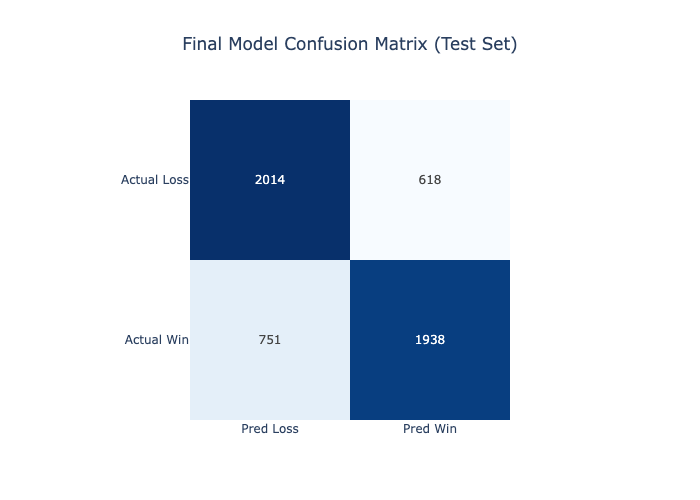

In [17]:
# Confusion matrix for the final model on the test set.
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, final_model.predict(X_test[FEATURES]))
fig = px.imshow(
    cm, text_auto=True, color_continuous_scale="Blues",
    x=["Pred Loss", "Pred Win"], y=["Actual Loss", "Actual Win"],
    title="Final Model Confusion Matrix (Test Set)",
)
fig.update_layout(title_x=0.5, coloraxis_showscale=False)
save_fig(fig, "confusion")
fig.show()

The final model improves on the baseline's test accuracy. The gain comes from giving
the model a fuller picture of the early game — all three objective flags, all three
resource differentials, and the two engineered summaries (`early_objectives` and
`gold_xp_sum`) — and from the Random Forest's ability to capture non-linear
interactions between them (e.g., a gold lead matters more when paired with objective
control). We attribute the improvement to these richer, well-motivated features rather
than to chance, since they were chosen from the data generating process before being
evaluated.

## Fairness Analysis

We ask: **does the final model predict outcomes equally well across leagues of
different competitive tiers?**

- **Group X — major leagues:** `LCK`, `LCS`, `LEC` (top Western/Korean leagues).
- **Group Y — all other leagues** present in the modeling data.
- **Evaluation metric:** accuracy.
- **Null hypothesis ($H_0$):** The model is fair — its accuracy on major leagues and on
  other leagues is the same, and any observed difference is due to chance.
- **Alternative hypothesis ($H_1$):** The model is unfair — its accuracy differs between
  the two groups.
- **Test statistic:** |accuracy(major) − accuracy(other)| (two-sided).
- **Significance level:** $\alpha = 0.05$.

We run a permutation test, shuffling the group labels on the test set.

In [18]:
MAJOR = {"LCK", "LCS", "LEC"}
test_eval = X_test.copy()
test_eval["y_true"] = y_test.values
test_eval["y_pred"] = final_model.predict(X_test[FEATURES])
test_eval["is_major"] = test_eval["league"].isin(MAJOR)
test_eval["correct"] = (test_eval["y_true"] == test_eval["y_pred"]).astype(int)

acc_major = test_eval[test_eval["is_major"]]["correct"].mean()
acc_other = test_eval[~test_eval["is_major"]]["correct"].mean()
obs_stat = abs(acc_major - acc_other)
print(f"Accuracy on major leagues (X): {acc_major:.4f}  (n={test_eval['is_major'].sum()})")
print(f"Accuracy on other leagues (Y): {acc_other:.4f}  (n={(~test_eval['is_major']).sum()})")
print(f"Observed |difference|:         {obs_stat:.4f}")

rng = np.random.default_rng(7)
correct = test_eval["correct"].values
group = test_eval["is_major"].values
n_reps = 10000
stats = np.empty(n_reps)
for i in range(n_reps):
    s = rng.permutation(group)
    stats[i] = abs(correct[s].mean() - correct[~s].mean())
p_fair = float(np.mean(stats >= obs_stat))
print(f"Permutation p-value: {p_fair:.4f}")

Accuracy on major leagues (X): 0.6911  (n=492)
Accuracy on other leagues (Y): 0.7480  (n=4829)
Observed |difference|:         0.0569
Permutation p-value: 0.0071


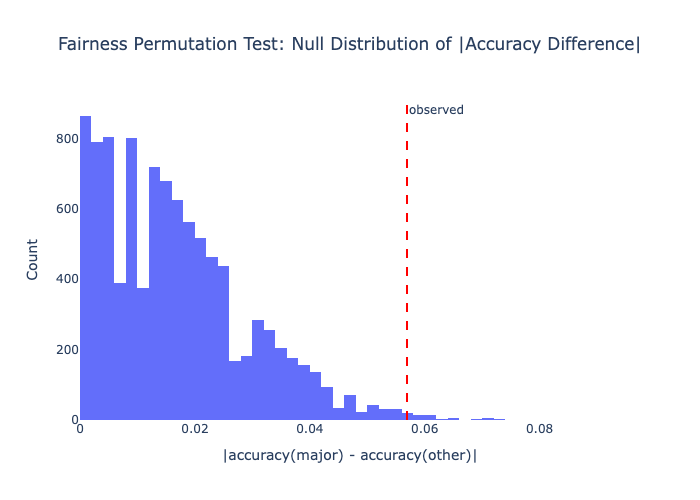

In [19]:
fig = px.histogram(
    pd.DataFrame({"stat": stats}), x="stat", nbins=50,
    title="Fairness Permutation Test: Null Distribution of |Accuracy Difference|",
    labels={"stat": "|accuracy(major) - accuracy(other)|"},
)
fig.add_vline(x=obs_stat, line_dash="dash", line_color="red",
              annotation_text="observed")
fig.update_layout(plot_bgcolor="white", title_x=0.5, yaxis_title="Count")
save_fig(fig, "fairness_perm")
fig.show()

**Conclusion.** The model achieved about **69.1% accuracy on major-league games** versus
**74.8% on other games**, an observed gap of ~5.7 percentage points, with a permutation
p-value of ~0.007. Because this is below $\alpha = 0.05$, we **reject the null
hypothesis**: there is evidence that the model performs worse on major-league games than
on other games. A plausible explanation is that elite teams play more even, drawn-out
games in which an early 15-minute lead is less decisive, making outcomes harder to predict
from early state alone. As with all our tests, this is a statistical conclusion on
observational data and does not prove unfairness with certainty.

---

### Summary

Starting from a single question — *does the first dragon matter?* — we cleaned the
Oracle's Elixir data, explored it, showed that `golddiffat15` is MAR (its missingness
depends on `league`, not `result`), confirmed via a permutation test that securing the
first dragon is associated with a markedly higher win rate, and then built a model that
predicts game outcomes from early-game state, improving from a ~73.7% baseline to a
~74.3% Random Forest final model, which a fairness test suggests is less accurate on
major-league games than on others.